In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [122]:
import requests
import time 
import warnings
warnings.filterwarnings('ignore')
API_TOKENS = "37882523c5a24cb1984f940e47cad7c8"
BASE_URL = 'https://api.football-data.org/v4'
HEADERS  = {'X-Auth-Token': API_TOKENS}

In [123]:
RO16_TEAMS = {
    'PSG':(524,'FL1'),
    'Chelsea':(61,'PL'),
    'Galatasaray':(610, None),   
    'Liverpool':(64,'PL'),
    'Man City': (65,'PL'),
    'Real Madrid':(86,'PD'),
    'Bayern Munich':(5,'BL1'),
    'Atalanta':(102,'SA'),
    'Bodo/Glimt':(5721, None),   
    'Arsenal':(57,'PL'),
    'Sporting CP':(498,'PPL'),
    'Leverkusen':(3,'BL1'),
    'Barcelona':(81,'PD'),
    'Newcastle':(67,'PL'),
    'Atletico Madrid':(78,'PD'),
    'Tottenham':(73,'PL'),
}
print(f'Config loaded tracking {len(RO16_TEAMS)} RO16 teams')

Config loaded tracking 16 RO16 teams


In [124]:
def api_get(endpoint, params=None):
    url = f'{BASE_URL}{endpoint}'
    try:
        r = requests.get(url, headers=HEADERS, params=params, timeout=15)
        if r.status_code == 200:     
            return r.json()
        elif r.status_code == 429:   
         print('Rate limited waiting 65 seconds'); time.sleep(65); 
         return api_get(endpoint, params)
        elif r.status_code == 403:   
         print(f'Access denied: {endpoint}'); 
         return None
        else:                        
         print(f'{r.status_code} for {endpoint}'); 
         return None
    except Exception as e:           
        print(f'{e}'); return None

def safe_get(d, *keys, default=0):
    for k in keys:
        if d is None: 
           return default
        d = d[k] if isinstance(d, list) else (d.get(k) if isinstance(d, dict) else None)
    return d if d is not None else default

print("Helpers are ready")

Helpers are ready


In [125]:
# 🔍 DIAGNOSTIC — run this first to see raw API response
print('Testing CL matches endpoint...\n')

# Test 1: basic fetch
data = api_get('/competitions/CL/matches', {'season': 2025})
print(f'Status: {"✅ Got data" if data else "❌ No data"}')

if data:
    print(f'Keys in response: {list(data.keys())}')
    matches = data.get('matches', [])
    print(f'Total matches found: {len(matches)}')
    
    if matches:
        # Show unique statuses
        statuses = set(m.get('status','?') for m in matches)
        print(f'Match statuses: {statuses}')
        
        # Show unique stages
        stages = set(m.get('stage','?') for m in matches)
        print(f'Match stages: {stages}')
        
        # Show first match raw
        print(f'\nFirst match raw data:')
        print(matches[0])

Testing CL matches endpoint...

Status: ✅ Got data
Keys in response: ['filters', 'resultSet', 'competition', 'matches']
Total matches found: 189
Match statuses: {'FINISHED', 'TIMED', 'SCHEDULED'}
Match stages: {'LAST_16', 'PLAYOFFS', 'QUARTER_FINALS', 'FINAL', 'LEAGUE_STAGE', 'SEMI_FINALS'}

First match raw data:
{'area': {'id': 2077, 'name': 'Europe', 'code': 'EUR', 'flag': 'https://crests.football-data.org/EUR.svg'}, 'competition': {'id': 2001, 'name': 'UEFA Champions League', 'code': 'CL', 'type': 'CUP', 'emblem': 'https://crests.football-data.org/CL.png'}, 'season': {'id': 2454, 'startDate': '2025-09-16', 'endDate': '2026-05-30', 'currentMatchday': 8, 'winner': None}, 'id': 551981, 'utcDate': '2025-09-16T16:45:00Z', 'status': 'FINISHED', 'matchday': 1, 'stage': 'LEAGUE_STAGE', 'group': None, 'lastUpdated': '2026-03-03T00:20:54Z', 'homeTeam': {'id': 77, 'name': 'Athletic Club', 'shortName': 'Athletic', 'tla': 'ATH', 'crest': 'https://crests.football-data.org/77.png'}, 'awayTeam': {'

In [126]:
import requests

API_TOKEN = '37882523c5a24cb1984f940e47cad7c8'
HEADERS = {'X-Auth-Token': API_TOKEN}

url = 'https://api.football-data.org/v4/competitions/CL/matches'
r = requests.get(url, headers=HEADERS, params={'season': 2025})

print('Status code:', r.status_code)
print('Response:', r.text[:1000])

Status code: 200
Response: {"filters":{"season":2025},"resultSet":{"count":189,"first":"2025-09-16","last":"2026-05-30","played":160},"competition":{"id":2001,"name":"UEFA Champions League","code":"CL","type":"CUP","emblem":"https://crests.football-data.org/CL.png"},"matches":[{"area":{"id":2077,"name":"Europe","code":"EUR","flag":"https://crests.football-data.org/EUR.svg"},"competition":{"id":2001,"name":"UEFA Champions League","code":"CL","type":"CUP","emblem":"https://crests.football-data.org/CL.png"},"season":{"id":2454,"startDate":"2025-09-16","endDate":"2026-05-30","currentMatchday":8,"winner":null},"id":551981,"utcDate":"2025-09-16T16:45:00Z","status":"FINISHED","matchday":1,"stage":"LEAGUE_STAGE","group":null,"lastUpdated":"2026-03-03T00:20:54Z","homeTeam":{"id":77,"name":"Athletic Club","shortName":"Athletic","tla":"ATH","crest":"https://crests.football-data.org/77.png"},"awayTeam":{"id":57,"name":"Arsenal FC","shortName":"Arsenal","tla":"ARS","crest":"https://crests.football-

In [127]:
def get_ucl_stats_from_matches():
    print('🔄 Fetching UCL 2025/26 matches...')
    data = api_get('/competitions/CL/matches', {'season': 2025})
    
    if not data:
        print('❌ Failed to fetch data')
        return pd.DataFrame()

    matches = data.get('matches', [])  # use .get directly, not safe_get
    finished = [m for m in matches if m.get('status') == 'FINISHED']
    league_phase = [m for m in finished if m.get('stage') == 'LEAGUE_STAGE']
    
    print(f'Total matches: {len(matches)}')
    print(f'Finished matches: {len(finished)}')
    print(f'League stage finished: {len(league_phase)}')

    if not league_phase:
        print('❌ No league stage matches found!')
        return pd.DataFrame()

    # Build per-team stats
    stats = {}
    for m in league_phase:
        home_id   = m['homeTeam']['id']
        away_id   = m['awayTeam']['id']
        home_name = m['homeTeam']['name']
        away_name = m['awayTeam']['name']
        hg = m['score']['fullTime']['home'] or 0
        ag = m['score']['fullTime']['away'] or 0

        for tid, tname, gf, ga in [(home_id, home_name, hg, ag),
                                    (away_id, away_name, ag, hg)]:
            if tid not in stats:
                stats[tid] = {
                    'team_id': tid, 'team_name': tname,
                    'ucl_played': 0, 'ucl_wins': 0, 'ucl_draws': 0,
                    'ucl_losses': 0, 'ucl_goals_for': 0, 'ucl_goals_against': 0
                }
            s = stats[tid]
            s['ucl_played']        += 1
            s['ucl_goals_for']     += gf
            s['ucl_goals_against'] += ga
            if gf > ga:    s['ucl_wins']   += 1
            elif gf == ga: s['ucl_draws']  += 1
            else:          s['ucl_losses'] += 1

    print(f'✅ Processed stats for {len(stats)} teams')

    if not stats:
        print('❌ stats dict is empty!')
        return pd.DataFrame()

    df = pd.DataFrame(list(stats.values()))
    df['ucl_points']     = df['ucl_wins'] * 3 + df['ucl_draws']
    df['ucl_goal_diff']  = df['ucl_goals_for'] - df['ucl_goals_against']
    df['ucl_win_rate']   = df['ucl_wins']         / df['ucl_played'].replace(0, 1)
    df['ucl_goals_pg']   = df['ucl_goals_for']     / df['ucl_played'].replace(0, 1)
    df['ucl_concede_pg'] = df['ucl_goals_against'] / df['ucl_played'].replace(0, 1)
    df = df.sort_values('ucl_points', ascending=False).reset_index(drop=True)

    print(f'✅ Done — {len(df)} teams in UCL df')
    return df

ucl_df = get_ucl_stats_from_matches()

# Preview RO16 teams only
ro16_ids = {tid for _, (tid, _) in RO16_TEAMS.items()}
ucl_df[ucl_df['team_id'].isin(ro16_ids)][['team_name','ucl_points','ucl_wins','ucl_goal_diff']]

🔄 Fetching UCL 2025/26 matches...
Total matches: 189
Finished matches: 160
League stage finished: 144
✅ Processed stats for 36 teams
✅ Done — 36 teams in UCL df


,team_name,ucl_points,ucl_wins,ucl_goal_diff
0,Arsenal FC,24,8,19
1,FC Bayern München,21,7,14
2,Liverpool FC,18,6,12
3,Tottenham Hotspur FC,17,5,10
4,FC Barcelona,16,5,8
5,Manchester City FC,16,5,6
6,Sporting Clube de Portugal,16,5,6
7,Chelsea FC,16,5,7
8,Real Madrid CF,15,5,9
10,Paris Saint-Germain FC,14,4,10


In [128]:
# Find correct IDs for Bodo/Glimt and Galatasaray from the UCL data
print("All teams in UCL data:")
print(ucl_df[['team_id', 'team_name', 'ucl_points']].to_string())

All teams in UCL data:
    team_id                    team_name  ucl_points
0        57                   Arsenal FC          24
1         5            FC Bayern München          21
2        64                 Liverpool FC          18
3        73         Tottenham Hotspur FC          17
4        81                 FC Barcelona          16
5        65           Manchester City FC          16
6       498   Sporting Clube de Portugal          16
7        61                   Chelsea FC          16
8        86               Real Madrid CF          15
9       108     FC Internazionale Milano          15
10      524       Paris Saint-Germain FC          14
11       67          Newcastle United FC          14
12      109                  Juventus FC          13
13       78      Club Atlético de Madrid          13
14      102                  Atalanta BC          13
15        3          Bayer 04 Leverkusen          12
16        4            Borussia Dortmund          11
17      654           P

In [129]:
# Search for Bodo in UCL data
print(ucl_df[ucl_df['team_name'].str.contains('Bod', case=False, na=False)][['team_id', 'team_name']])

    team_id      team_name
26     5721  FK Bodø/Glimt


In [130]:
def get_league_standings(league_code):
    data = api_get(f'/competitions/{league_code}/standings', {'season': 2025})
    if not data: return {}
    result = {}
    for group in data.get('standings', []):
        if group.get('type') == 'TOTAL':
            table = group.get('table', [])
            for row in table:
                tid = row['team']['id']
                result[tid] = {
                    'league_position':      row.get('position', 0),
                    'league_total_teams':   len(table),
                    'league_points':        row.get('points', 0),
                    'league_played':        row.get('playedGames', 0),
                    'league_wins':          row.get('won', 0),
                    'league_draws':         row.get('draw', 0),
                    'league_losses':        row.get('lost', 0),
                    'league_goals_for':     row.get('goalsFor', 0),
                    'league_goals_against': row.get('goalsAgainst', 0),
                    'league_goal_diff':     row.get('goalDifference', 0),
                }
    return result

# Manual fallback for leagues not on free tier
MANUAL_STATS = {
    610:  {  # Galatasaray — Süper Lig (approx 2025/26)
        'league_position':1,'league_total_teams':19,'league_points':52,
        'league_played':22,'league_wins':16,'league_draws':4,'league_losses':2,
        'league_goals_for':52,'league_goals_against':18,'league_goal_diff':34
    },
    5721: {  # Bodo/Glimt — Eliteserien (approx 2025/26)
        'league_position':1,'league_total_teams':16,'league_points':62,
        'league_played':30,'league_wins':19,'league_draws':5,'league_losses':6,
        'league_goals_for':70,'league_goals_against':38,'league_goal_diff':32
    },
}

leagues = set(code for _, (_, code) in RO16_TEAMS.items() if code)
print(f'📡 Fetching {len(leagues)} leagues: {leagues}\n')

all_league_data = {}
for lg in leagues:
    print(f'  🔄 {lg}...')
    result = get_league_standings(lg)
    if result:
        all_league_data.update(result)
        print(f'     ✅ {len(result)} teams fetched')
    else:
        print(f'     ❌ Failed or not on free tier')
    time.sleep(7)

# Apply manual fallbacks
for tid, stats in MANUAL_STATS.items():
    if tid not in all_league_data:
        all_league_data[tid] = stats
        name = [n for n, (i, _) in RO16_TEAMS.items() if i == tid][0]
        print(f'  📝 Manual stats applied for {name}')

print(f'\n✅ Domestic stats ready for {len(all_league_data)} teams total')

📡 Fetching 6 leagues: {'PPL', 'BL1', 'PD', 'FL1', 'PL', 'SA'}

  🔄 PPL...
     ✅ 18 teams fetched
  🔄 BL1...
     ✅ 18 teams fetched
  🔄 PD...
     ✅ 20 teams fetched
  🔄 FL1...
     ✅ 18 teams fetched
  🔄 PL...
     ✅ 20 teams fetched
  🔄 SA...
     ✅ 20 teams fetched
  📝 Manual stats applied for Galatasaray
  📝 Manual stats applied for Bodo/Glimt

✅ Domestic stats ready for 116 teams total


In [131]:
def get_recent_form(team_id, last_n=5):
    data = api_get(f'/teams/{team_id}/matches', {
        'status': 'FINISHED',
        'limit': last_n + 2
    })
    if not data:
        return {'form_pts':0,'form_gf':0,'form_ga':0,'form_wins':0,'form_gd':0}

    matches = data.get('matches', [])[-last_n:]
    pts, gf, ga, wins = 0, 0, 0, 0

    for m in matches:
        hid = m['homeTeam']['id']
        hg  = m['score']['fullTime']['home'] or 0
        ag  = m['score']['fullTime']['away'] or 0
        my, opp = (hg, ag) if hid == team_id else (ag, hg)
        gf += my; ga += opp
        if my > opp:    pts += 3; wins += 1
        elif my == opp: pts += 1

    return {'form_pts':pts,'form_gf':gf,'form_ga':ga,'form_wins':wins,'form_gd':gf-ga}

print('📡 Fetching recent form for all 16 RO16 teams...\n')
form_data = {}
for name, (tid, _) in RO16_TEAMS.items():
    print(f'  🔄 {name}...')
    form_data[tid] = get_recent_form(tid)
    time.sleep(7)

print('\n✅ Form data collected!')
pd.DataFrame([
    {'team': name, **form_data[tid]}
    for name, (tid, _) in RO16_TEAMS.items()
]).sort_values('form_pts', ascending=False)

📡 Fetching recent form for all 16 RO16 teams...

  🔄 PSG...
  🔄 Chelsea...
  🔄 Galatasaray...
  🔄 Liverpool...
  🔄 Man City...
  🔄 Real Madrid...
  🔄 Bayern Munich...
  🔄 Atalanta...
  🔄 Bodo/Glimt...
  🔄 Arsenal...
  🔄 Sporting CP...
  🔄 Leverkusen...
  🔄 Barcelona...
  🔄 Newcastle...
  🔄 Atletico Madrid...
  🔄 Tottenham...

✅ Form data collected!


,team,form_pts,form_gf,form_ga,form_wins,form_gd
6,Bayern Munich,13,16,7,4,9
4,Man City,13,10,4,4,6
10,Sporting CP,13,10,2,4,8
8,Bodo/Glimt,13,12,6,4,6
3,Liverpool,12,12,5,4,7
12,Barcelona,12,14,4,4,10
9,Arsenal,11,12,5,3,7
0,PSG,10,10,7,3,3
14,Atletico Madrid,10,12,9,3,3
13,Newcastle,9,14,9,3,5


In [132]:
# Search for Bodo in UCL data
print(ucl_df[ucl_df['team_name'].str.contains('Atal', case=False, na=False)][['team_id', 'team_name']])

    team_id    team_name
14      102  Atalanta BC


In [133]:
id_to_ucl = ucl_df.set_index('team_id').to_dict('index')

rows = []
for name, (tid, _) in RO16_TEAMS.items():
    row = {'team': name, 'team_id': tid}

    # UCL stats
    ucl = id_to_ucl.get(tid, {})
    for c in ['ucl_points','ucl_wins','ucl_draws','ucl_losses',
              'ucl_goal_diff','ucl_goals_for','ucl_goals_against',
              'ucl_win_rate','ucl_goals_pg','ucl_concede_pg']:
        row[c] = ucl.get(c, 0)

    # League stats
    lg = all_league_data.get(tid, {})
    for c in ['league_position','league_total_teams','league_points',
              'league_played','league_wins','league_draws','league_losses',
              'league_goals_for','league_goals_against','league_goal_diff']:
        row[c] = lg.get(c, 0)

    # Form stats
    f = form_data.get(tid, {})
    row.update({
        'form_pts':  f.get('form_pts',  0),
        'form_wins': f.get('form_wins', 0),
        'form_gf':   f.get('form_gf',   0),
        'form_ga':   f.get('form_ga',   0),
        'form_gd':   f.get('form_gd',   0),
    })

    # Derived features
    total  = max(row['league_total_teams'], 1)
    played = max(row['league_played'], 1)
    row['league_pos_pct']    = 1 - (row['league_position'] / total)  # 1.0 = top of league
    row['league_win_rate']   = row['league_wins']         / played
    row['league_goals_pg']   = row['league_goals_for']    / played
    row['league_concede_pg'] = row['league_goals_against']/ played

    rows.append(row)

master = pd.DataFrame(rows)
print(f'✅ Master DataFrame: {master.shape[0]} teams × {master.shape[1]} features')
print(f'\n⚠️  Teams with zero league data (check manually):')
print(master[master['league_points'] == 0][['team','league_points']])
master[['team','ucl_points','ucl_goal_diff','league_pos_pct','league_goal_diff','form_pts']]

✅ Master DataFrame: 16 teams × 31 features

⚠️  Teams with zero league data (check manually):
Empty DataFrame
Columns: [team, league_points]
Index: []


,team,ucl_points,ucl_goal_diff,league_pos_pct,league_goal_diff,form_pts
0,PSG,14,10,0.944444,34,10
1,Chelsea,16,7,0.700000,16,8
2,Galatasaray,10,-2,0.947368,34,4
3,Liverpool,18,12,0.750000,10,12
4,Man City,16,6,0.900000,32,13
5,Real Madrid,15,9,0.900000,32,9
6,Bayern Munich,21,14,0.944444,65,13
7,Atalanta,13,0,0.650000,13,9
8,Bodo/Glimt,9,-1,0.937500,32,13
9,Arsenal,24,19,0.950000,36,11


In [134]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler

In [135]:

FEATURES = [
    'ucl_points', 'ucl_wins', 'ucl_goal_diff',
    'ucl_win_rate', 'ucl_goals_pg', 'ucl_concede_pg',
    'league_pos_pct', 'league_win_rate', 'league_goal_diff',
    'league_goals_pg', 'league_concede_pg', 'league_points',
    'form_pts', 'form_wins', 'form_gd',
]

X = master[FEATURES].fillna(0)
scaler = MinMaxScaler()
X_sc = scaler.fit_transform(X)
X_sc_df = pd.DataFrame(X_sc, columns=FEATURES)

# Domain-weighted composite score as training target
W = {
    'ucl_points':       0.20,
    'ucl_wins':         0.10,
    'ucl_goal_diff':    0.10,
    'ucl_win_rate':     0.10,
    'ucl_goals_pg':     0.05,
    'ucl_concede_pg':  -0.05,
    'league_pos_pct':   0.12,
    'league_win_rate':  0.08,
    'league_goal_diff': 0.07,
    'league_goals_pg':  0.04,
    'league_concede_pg':-0.04,
    'league_points':    0.05,
    'form_pts':         0.10,
    'form_wins':        0.05,
    'form_gd':          0.05,
}

y = sum(W.get(f, 0) * X_sc_df[f] for f in FEATURES)

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_sc, y)

# Convert predictions to win probabilities
raw   = rf.predict(X_sc)
probs = np.exp(raw * 12)
probs = probs / probs.sum() * 100

master['win_prob']  = probs
master['raw_score'] = raw

print('✅ Random Forest trained!')
print(f'\nQuick sanity check — probabilities sum to: {probs.sum():.1f}%')

,n_estimators,1000
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


✅ Random Forest trained!

Quick sanity check — probabilities sum to: 100.0%


     🏆  UCL 2025/26 WINNER PREDICTIONS
#    Team                     Win Prob  UCL Pts   Form
------------------------------------------------------------
🥇 1   Bayern Munich             42.20%      21     13
🥈 2   Arsenal                   27.13%      24     11
🥉 3   Barcelona                 14.95%      16     12
   4   Sporting CP                6.52%      16     13
   5   Liverpool                  2.52%      18     12
   6   Man City                   1.68%      16     13
   7   Real Madrid                1.58%      15      9
   8   PSG                        1.51%      14     10
   9   Bodo/Glimt                 0.61%       9     13
   10  Atletico Madrid            0.35%      13     10
   11  Chelsea                    0.32%      16      8
   12  Galatasaray                0.18%      10      4
   13  Atalanta                   0.13%      13      9
   14  Newcastle                  0.13%      14      9
   15  Tottenham                  0.12%      17      1
   16  Leverkusen      

Text(0.28223830368437974, 0.0, '0.1%')

Text(0.31674277733289713, 1.0, '0.1%')

Text(0.3265001745803847, 2.0, '0.1%')

Text(0.32948505377050874, 3.0, '0.1%')

Text(0.3815902908441027, 4.0, '0.2%')

Text(0.5165729159801655, 5.0, '0.3%')

Text(0.5451140292955063, 6.0, '0.3%')

Text(0.8082910100965668, 7.0, '0.6%')

Text(1.7138554478365369, 8.0, '1.5%')

Text(1.7779048109809112, 9.0, '1.6%')

Text(1.8809135894145055, 10.0, '1.7%')

Text(2.719839773145602, 11.0, '2.5%')

Text(6.722847085378665, 12.0, '6.5%')

Text(15.1489901484564, 13.0, '14.9%')

Text(27.33177790077557, 14.0, '27.1%')

Text(42.397336688427295, 15.0, '42.2%')

Text(0.5, 1.0, '🏆 UCL 2025/26 — Predicted Winner Probabilities\nRandom Forest | UCL League Stage + Domestic League + Recent Form')

Text(0.5, 0, 'Win Probability (%)')

(0.0, 49.7928572923442)

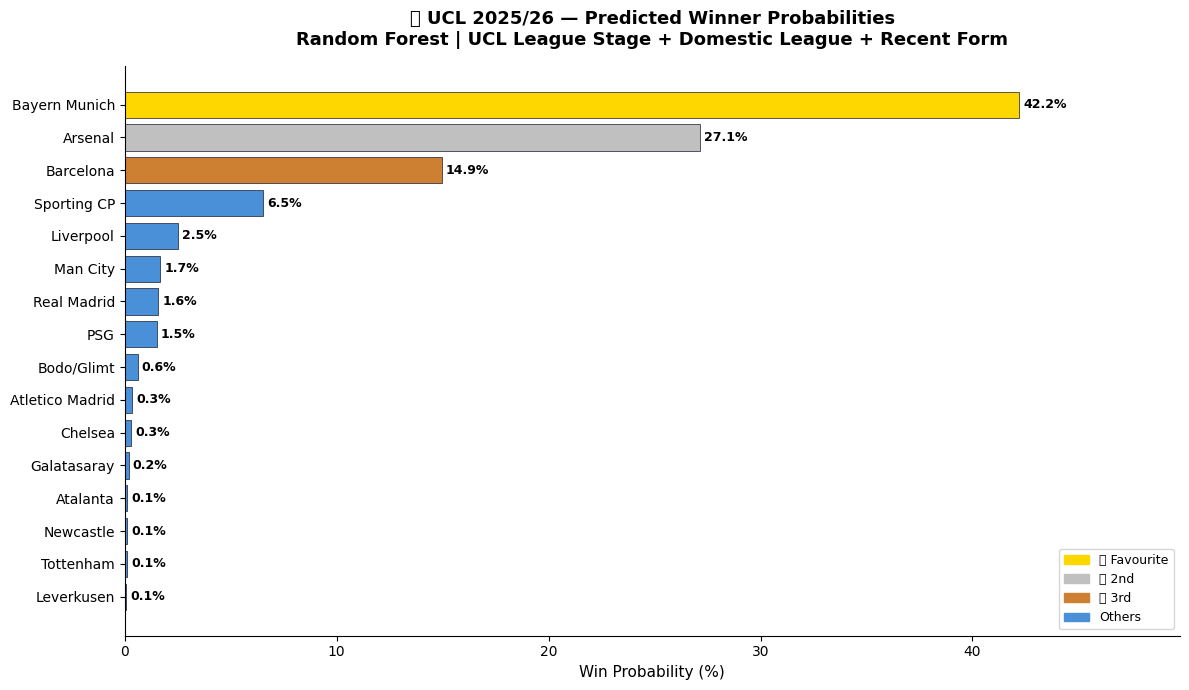

📊 Saved → ucl_2526_predictions.png


In [136]:

import matplotlib.patches as mpatches

res = master[['team','win_prob','ucl_points','ucl_goal_diff','form_pts']] \
      .sort_values('win_prob', ascending=False).reset_index(drop=True)
res.index += 1

# Print table
print('=' * 60)
print('     🏆  UCL 2025/26 WINNER PREDICTIONS')
print('=' * 60)
print(f'{"#":<4} {"Team":<22} {"Win Prob":>10} {"UCL Pts":>8} {"Form":>6}')
print('-' * 60)
medals = {1:'🥇', 2:'🥈', 3:'🥉'}
for i, row in res.iterrows():
    m = medals.get(i, '  ')
    print(f'{m} {i:<3} {row["team"]:<22} {row["win_prob"]:>8.2f}%  '
          f'{int(row["ucl_points"]):>6}   {int(row["form_pts"]):>4}')
print('=' * 60)

#Bar chart
fig, ax = plt.subplots(figsize=(12, 7))
palette = ['#FFD700', '#C0C0C0', '#CD7F32'] + ['#4A90D9'] * 13
colors  = [palette[i-1] for i in res.index]

bars = ax.barh(
    res['team'][::-1],
    res['win_prob'][::-1],
    color=colors[::-1],
    edgecolor='#1a1a2e',
    linewidth=0.5
)

for bar, val in zip(bars, res['win_prob'][::-1]):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_title(
    '🏆 UCL 2025/26 — Predicted Winner Probabilities\n'
    'Random Forest | UCL League Stage + Domestic League + Recent Form',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Win Probability (%)', fontsize=11)
ax.set_xlim(0, res['win_prob'].max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color='#FFD700', label='🥇 Favourite'),
    mpatches.Patch(color='#C0C0C0', label='🥈 2nd'),
    mpatches.Patch(color='#CD7F32', label='🥉 3rd'),
    mpatches.Patch(color='#4A90D9', label='Others'),
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('ucl_2526_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved → ucl_2526_predictions.png')

<Axes: >

Text(0.5, 1.0, '📊 Feature Importance — What drives UCL success?')

Text(0.5, 0, 'Importance Score')

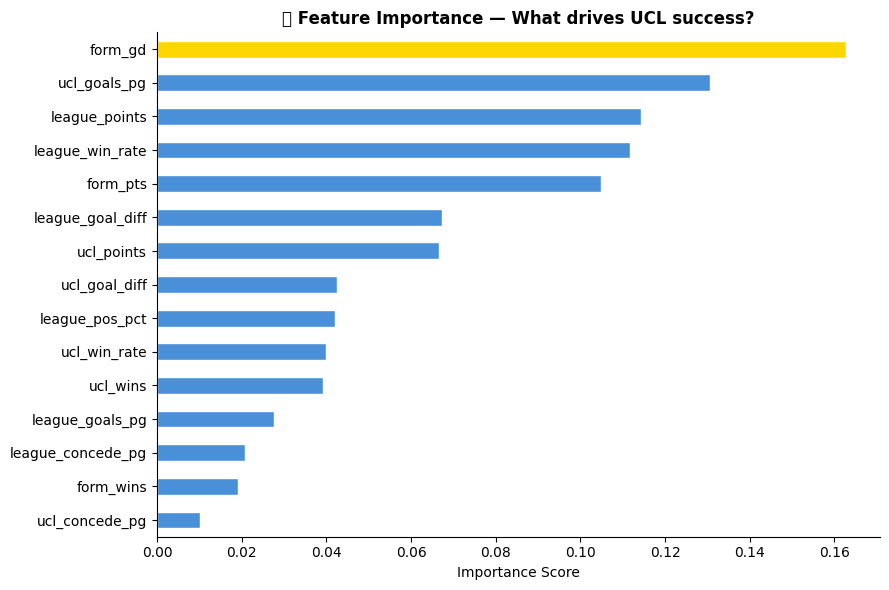


Top 5 Features:
  form_gd                        0.1626
  ucl_goals_pg                   0.1307
  league_points                  0.1144
  league_win_rate                0.1118
  form_pts                       0.1049


In [137]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#FFD700' if v == imp.max() else '#4A90D9' for v in imp]
imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('📊 Feature Importance — What drives UCL success?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nTop 5 Features:')
for f, v in imp.sort_values(ascending=False).head(5).items():
    print(f'  {f:<30} {v:.4f}')

In [138]:
master.sort_values('win_prob', ascending=False).to_csv('ucl_2526_predictions.csv', index=False)
print('✅ Saved → ucl_2526_predictions.csv')
winner = master.loc[master['win_prob'].idxmax()]
print(f'\n🏆 PREDICTED UCL 2025/26 WINNER: {winner["team"]} ({winner["win_prob"]:.1f}%)')

✅ Saved → ucl_2526_predictions.csv

🏆 PREDICTED UCL 2025/26 WINNER: Bayern Munich (42.2%)


In [139]:
# Get final league stage rankings to determine home legs
print("UCL League Stage Final Rankings:")
ucl_ranked = ucl_df.sort_values('ucl_points', ascending=False).reset_index(drop=True)
ucl_ranked.index += 1
print(ucl_ranked[['team_id', 'team_name', 'ucl_points', 'ucl_goal_diff']].to_string())

UCL League Stage Final Rankings:
    team_id                    team_name  ucl_points  ucl_goal_diff
1        57                   Arsenal FC          24             19
2         5            FC Bayern München          21             14
3        64                 Liverpool FC          18             12
4        73         Tottenham Hotspur FC          17             10
5        81                 FC Barcelona          16              8
6        65           Manchester City FC          16              6
7       498   Sporting Clube de Portugal          16              6
8        61                   Chelsea FC          16              7
9        86               Real Madrid CF          15              9
10      108     FC Internazionale Milano          15              8
11      524       Paris Saint-Germain FC          14             10
12       67          Newcastle United FC          14             10
13      109                  Juventus FC          13              4
14       78    

In [142]:
# ================================================
# CELL 11 — UCL 2025/26 Full Bracket Simulator
# ================================================

import numpy as np

# Top 8 finished teams — play SECOND leg at HOME
TOP_8 = ['Arsenal', 'Bayern Munich', 'Liverpool', 'Tottenham',
          'Barcelona', 'Man City', 'Sporting CP', 'Chelsea']

def get_attack(team):
    row = master[master['team'] == team].iloc[0]
    return (row['ucl_goals_pg'] * 0.40 +
            row['league_goals_pg'] * 0.35 +
            (row['form_gf'] / 5) * 0.25)

def get_defence(team):
    row = master[master['team'] == team].iloc[0]
    return (row['ucl_concede_pg'] * 0.40 +
            row['league_concede_pg'] * 0.35 +
            (row['form_ga'] / 5) * 0.25)

def predict_score(att_team, def_team, home=True):
    """Predict goals using Poisson distribution for realistic scorelines."""
    xg = (get_attack(att_team) + get_defence(def_team)) / 2
    xg *= 1.08 if home else 0.93
    xg = max(0.3, xg)
    return int(np.random.poisson(xg))  # ✅ Poisson fix

def predict_tie(team_a, team_b):
    a_is_top8 = team_a in TOP_8
    b_is_top8 = team_b in TOP_8

    if a_is_top8 and not b_is_top8:
        leg1_home, leg1_away = team_b, team_a
        leg2_home, leg2_away = team_a, team_b
    elif b_is_top8 and not a_is_top8:
        leg1_home, leg1_away = team_a, team_b
        leg2_home, leg2_away = team_b, team_a
    else:
        pts_a = master[master['team'] == team_a]['ucl_points'].values[0]
        pts_b = master[master['team'] == team_b]['ucl_points'].values[0]
        if pts_a >= pts_b:
            leg1_home, leg1_away = team_b, team_a
            leg2_home, leg2_away = team_a, team_b
        else:
            leg1_home, leg1_away = team_a, team_b
            leg2_home, leg2_away = team_b, team_a

    leg1_hg = predict_score(leg1_home, leg1_away, home=True)
    leg1_ag = predict_score(leg1_away, leg1_home, home=False)
    leg2_hg = predict_score(leg2_home, leg2_away, home=True)
    leg2_ag = predict_score(leg2_away, leg2_home, home=False)

    if leg1_home == team_a:
        agg_a = leg1_hg + leg2_ag
        agg_b = leg1_ag + leg2_hg
    else:
        agg_a = leg1_ag + leg2_hg
        agg_b = leg1_hg + leg2_ag

    if agg_a > agg_b:
        winner = team_a
    elif agg_b > agg_a:
        winner = team_b
    else:
        prob_a = master[master['team'] == team_a]['win_prob'].values[0]
        prob_b = master[master['team'] == team_b]['win_prob'].values[0]
        winner = team_a if prob_a >= prob_b else team_b

    return {
        'team_a': team_a,
        'team_b': team_b,
        'leg1': f"{leg1_home} {leg1_hg}-{leg1_ag} {leg1_away}",
        'leg2': f"{leg2_home} {leg2_hg}-{leg2_ag} {leg2_away}",
        'agg_a': agg_a,
        'agg_b': agg_b,
        'winner': winner,
    }

def print_round(round_name, fixtures):
    print(f'\n{"="*65}')
    print(f'  {round_name}')
    print(f'{"="*65}')
    winners = []
    for team_a, team_b in fixtures:
        r = predict_tie(team_a, team_b)
        agg_str = f"{r['team_a']} {r['agg_a']}-{r['agg_b']} {r['team_b']}"
        pens = ' (on pens)' if r['agg_a'] == r['agg_b'] else ''
        print(f'\n  {r["team_a"]}  vs  {r["team_b"]}')
        print(f'  Leg 1 : {r["leg1"]}')
        print(f'  Leg 2 : {r["leg2"]}')
        print(f'  Agg   : {agg_str}{pens}')
        print(f'  ✅ {r["winner"]} advances')
        winners.append(r['winner'])
    return winners

# ── RO16 Fixtures ─────────────────────────────────
ro16_left = [
    ('Chelsea',       'PSG'),
    ('Liverpool',     'Galatasaray'),
    ('Man City',      'Real Madrid'),
    ('Bayern Munich', 'Atalanta'),
]

ro16_right = [
    ('Barcelona',      'Newcastle'),
    ('Tottenham',      'Atletico Madrid'),
    ('Sporting CP',    'Bodo/Glimt'),
    ('Arsenal',        'Leverkusen'),
]

# ── Run Full Bracket ──────────────────────────────
print('★'*65)
print('   🏆  UCL 2025/26 FULL BRACKET PREDICTION')
print('   🏟️  Final: Budapest, May 2026')
print('★'*65)

ro16_w_left  = print_round('⚔️  ROUND OF 16 — LEFT BRACKET',  ro16_left)
ro16_w_right = print_round('⚔️  ROUND OF 16 — RIGHT BRACKET', ro16_right)

qf_left  = [(ro16_w_left[0],  ro16_w_left[1]),  (ro16_w_left[2],  ro16_w_left[3])]
qf_right = [(ro16_w_right[0], ro16_w_right[1]), (ro16_w_right[2], ro16_w_right[3])]

qf_w_left  = print_round('⚔️  QUARTER FINALS — LEFT BRACKET',  qf_left)
qf_w_right = print_round('⚔️  QUARTER FINALS — RIGHT BRACKET', qf_right)

sf_fixtures = [(qf_w_left[0], qf_w_left[1]), (qf_w_right[0], qf_w_right[1])]
sf_winners  = print_round('⚔️  SEMI FINALS', sf_fixtures)

# ── Final ─────────────────────────────────────────
f1, f2 = sf_winners[0], sf_winners[1]
final_hg = predict_score(f1, f2, home=False)
final_ag = predict_score(f2, f1, home=False)

if final_hg > final_ag:     champion = f1
elif final_ag > final_hg:   champion = f2
else:
    prob1 = master[master['team'] == f1]['win_prob'].values[0]
    prob2 = master[master['team'] == f2]['win_prob'].values[0]
    champion = f1 if prob1 >= prob2 else f2

print(f'\n{"="*65}')
print(f'  🏆  FINAL — Budapest, May 30 2026')
print(f'{"="*65}')
print(f'\n  🏟️  {f1}  vs  {f2}')
print(f'  Score : {f1} {final_hg} - {final_ag} {f2}')
if final_hg == final_ag:
    print(f'  (Goes to penalties)')
print(f'\n{"="*65}')
print(f'  📋  FULL RESULTS SUMMARY')
print(f'{"="*65}')
print(f'  RO16 Winners : {", ".join(ro16_w_left + ro16_w_right)}')
print(f'  QF Winners   : {", ".join(qf_w_left + qf_w_right)}')
print(f'  SF Winners   : {", ".join(sf_winners)}')
print(f'  🏆 CHAMPION  : {champion}')
print(f'\n{"🏆"*15}')
print(f'  UCL 2025/26 CHAMPION: {champion.upper()}')
print(f'{"🏆"*15}')

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
   🏆  UCL 2025/26 FULL BRACKET PREDICTION
   🏟️  Final: Budapest, May 2026
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  ⚔️  ROUND OF 16 — LEFT BRACKET

  Chelsea  vs  PSG
  Leg 1 : PSG 1-0 Chelsea
  Leg 2 : Chelsea 3-1 PSG
  Agg   : Chelsea 3-2 PSG
  ✅ Chelsea advances

  Liverpool  vs  Galatasaray
  Leg 1 : Galatasaray 0-0 Liverpool
  Leg 2 : Liverpool 2-1 Galatasaray
  Agg   : Liverpool 2-1 Galatasaray
  ✅ Liverpool advances

  Man City  vs  Real Madrid
  Leg 1 : Real Madrid 1-0 Man City
  Leg 2 : Man City 4-0 Real Madrid
  Agg   : Man City 4-1 Real Madrid
  ✅ Man City advances

  Bayern Munich  vs  Atalanta
  Leg 1 : Atalanta 2-4 Bayern Munich
  Leg 2 : Bayern Munich 4-2 Atalanta
  Agg   : Bayern Munich 8-4 Atalanta
  ✅ Bayern Munich advances

  ⚔️  ROUND OF 16 — RIGHT BRACKET

  Barcelona  vs  Newcastle
  Leg 1 : Newcastle 5-1 Barcelona
  Leg 2 : Barcelona 2-2 Newcastle
  Agg   : Barcelona 3-7

In [143]:
# CELL 12 — Save Full Bracket to Text File

def run_and_save_bracket():
    lines = []
    lines.append('★'*65)
    lines.append('   🏆  UCL 2025/26 FULL BRACKET PREDICTION')
    lines.append('   🏟️  Final: Budapest, May 2026')
    lines.append('★'*65)

    def save_round(round_name, fixtures):
        lines.append(f'\n{"="*65}')
        lines.append(f'  {round_name}')
        lines.append(f'{"="*65}')
        winners = []
        for team_a, team_b in fixtures:
            r = predict_tie(team_a, team_b)
            agg_str = f"{r['team_a']} {r['agg_a']}-{r['agg_b']} {r['team_b']}"
            pens = ' (on pens)' if r['agg_a'] == r['agg_b'] else ''
            lines.append(f'\n  {r["team_a"]}  vs  {r["team_b"]}')
            lines.append(f'  Leg 1 : {r["leg1"]}')
            lines.append(f'  Leg 2 : {r["leg2"]}')
            lines.append(f'  Agg   : {agg_str}{pens}')
            lines.append(f'  ✅ {r["winner"]} advances')
            winners.append(r['winner'])
        return winners

    # RO16
    w_left  = save_round('⚔️  ROUND OF 16 — LEFT BRACKET',  ro16_left)
    w_right = save_round('⚔️  ROUND OF 16 — RIGHT BRACKET', ro16_right)

    # QF
    qf_left  = [(w_left[0],  w_left[1]),  (w_left[2],  w_left[3])]
    qf_right = [(w_right[0], w_right[1]), (w_right[2], w_right[3])]
    qf_w_left  = save_round('⚔️  QUARTER FINALS — LEFT BRACKET',  qf_left)
    qf_w_right = save_round('⚔️  QUARTER FINALS — RIGHT BRACKET', qf_right)

    # SF
    sf = [(qf_w_left[0], qf_w_left[1]), (qf_w_right[0], qf_w_right[1])]
    sf_w = save_round('⚔️  SEMI FINALS', sf)

    # Final
    f1, f2 = sf_w[0], sf_w[1]
    final_hg = predict_score(f1, f2, home=False)
    final_ag = predict_score(f2, f1, home=False)

    if final_hg > final_ag:     champion = f1
    elif final_ag > final_hg:   champion = f2
    else:
        prob1 = master[master['team'] == f1]['win_prob'].values[0]
        prob2 = master[master['team'] == f2]['win_prob'].values[0]
        champion = f1 if prob1 >= prob2 else f2

    lines.append(f'\n{"="*65}')
    lines.append(f'  🏆  FINAL — Budapest, May 30 2026')
    lines.append(f'{"="*65}')
    lines.append(f'\n  🏟️  {f1}  vs  {f2}')
    lines.append(f'  Score : {f1} {final_hg} - {final_ag} {f2}')
    if final_hg == final_ag:
        lines.append(f'  (Goes to penalties)')
    lines.append(f'\n{"="*65}')
    lines.append(f'  📋  FULL RESULTS SUMMARY')
    lines.append(f'{"="*65}')
    lines.append(f'  RO16 Winners : {", ".join(w_left + w_right)}')
    lines.append(f'  QF Winners   : {", ".join(qf_w_left + qf_w_right)}')
    lines.append(f'  SF Winners   : {", ".join(sf_w)}')
    lines.append(f'  🏆 CHAMPION  : {champion}')
    lines.append(f'\n{"🏆"*15}')
    lines.append(f'  UCL 2025/26 CHAMPION: {champion.upper()}')
    lines.append(f'{"🏆"*15}')

    return lines, champion

lines, champion = run_and_save_bracket()

# Save to txt
with open('ucl_bracket_prediction.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print(f'✅ Saved → ucl_bracket_prediction.txt')
print(f'🏆 PREDICTED CHAMPION: {champion}')

3961

✅ Saved → ucl_bracket_prediction.txt
🏆 PREDICTED CHAMPION: Arsenal
